In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
df = pd.read_csv("Housing.csv")
print(df.head(10))
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [23]:
df = df.drop_duplicates()

In [24]:
df = df.fillna(df.mode().iloc[0])

In [25]:
categorical_cols = df.select_dtypes(include='object').columns

df = pd.get_dummies(df,
                    columns=categorical_cols,
                    drop_first=True)

print(df.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

In [26]:
y = df['price']
X = df.drop('price', axis=1)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
r2_lr = r2_score(y_test, lr_pred)
print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R2 Score: 0.6529242642153184


In [29]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)
print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 1013968.579587156
RMSE: 1398115.6668385956
R2 Score: 0.6132752494107068


In [30]:
comparison = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'MAE':[mae_lr,mae_rf],
    'RMSE':[rmse_lr,rmse_rf],
    'R2':[r2_lr,r2_rf]
})
print(comparison)

               Model           MAE          RMSE        R2
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.013969e+06  1.398116e+06  0.613275


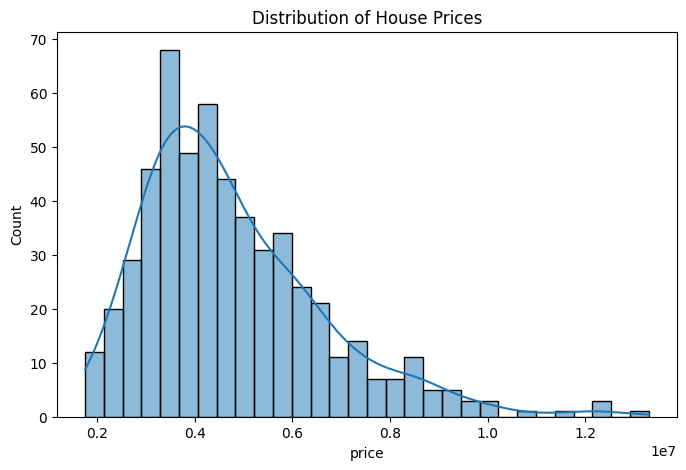

In [31]:
# @title
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.savefig("price_distribution.png")
plt.show()

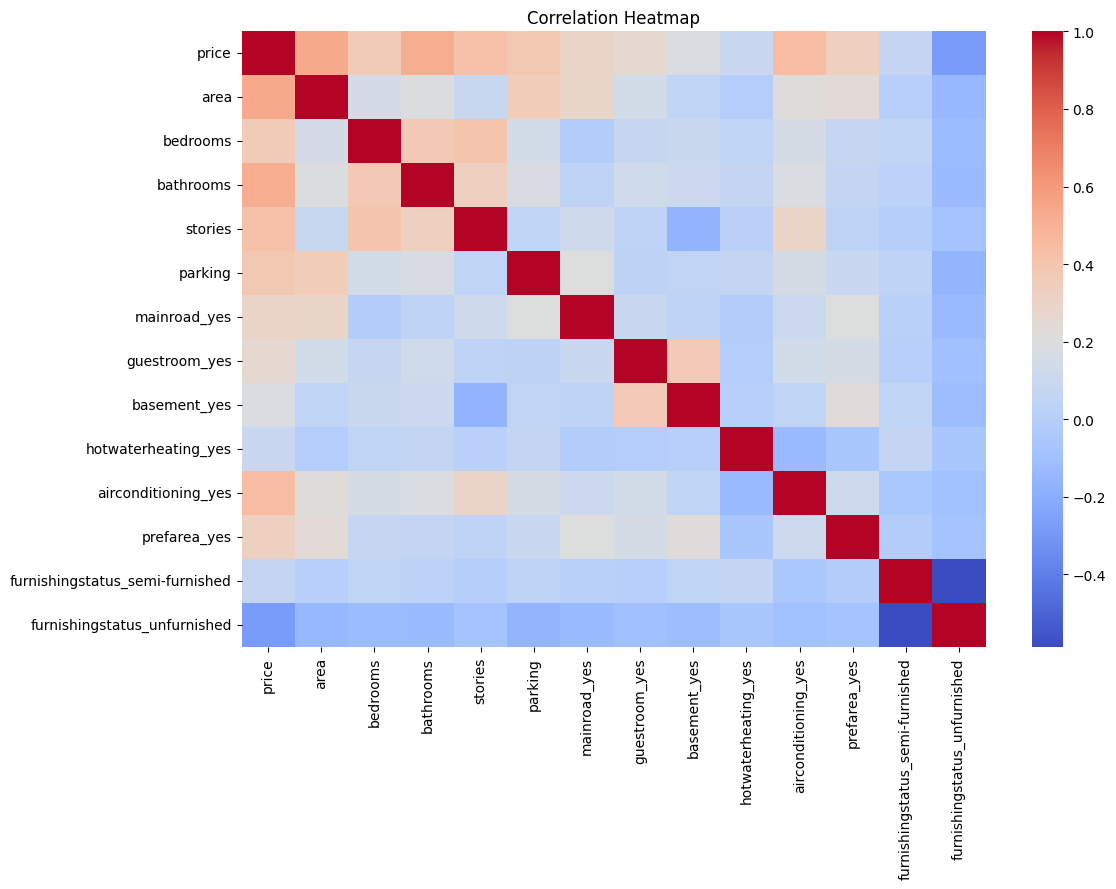

In [32]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(
    corr,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

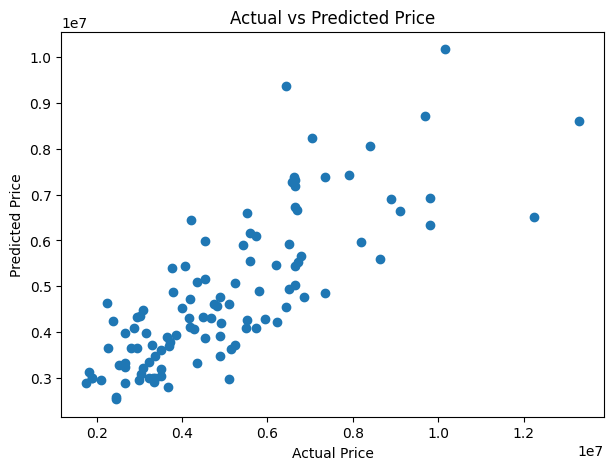

In [33]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.savefig("actual_vs_predicted.png")
plt.show()

In [34]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
print(importance.head(10))

                         Feature  Importance
0                           area    0.468535
2                      bathrooms    0.152554
9            airconditioning_yes    0.060238
4                        parking    0.057273
3                        stories    0.057064
1                       bedrooms    0.047370
12  furnishingstatus_unfurnished    0.036972
7                   basement_yes    0.032176
10                  prefarea_yes    0.028432
8            hotwaterheating_yes    0.018305
